In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

In [6]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
df.shape

(10000, 14)

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [9]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [10]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [11]:
failure_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df[failure_columns].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [12]:
df["failure_type_count"] = df[failure_columns].sum(axis=1)

df["failure_type_count"].value_counts().sort_index()

failure_type_count
0    9652
1     324
2      23
3       1
Name: count, dtype: int64

In [13]:
pd.crosstab(
    df["Machine failure"],
    df["failure_type_count"]
)

failure_type_count,0,1,2,3
Machine failure,,,,
0,9643,18,0,0
1,9,306,23,1


In [14]:
feature_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[feature_columns].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


In [15]:
df.groupby("Machine failure")[feature_columns].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


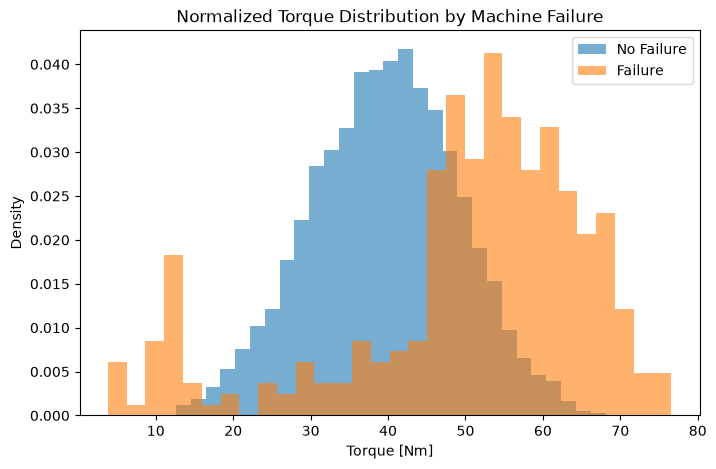

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Machine failure"] == 0]["Torque [Nm]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="No Failure"
)

plt.hist(
    df[df["Machine failure"] == 1]["Torque [Nm]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Failure"
)

plt.xlabel("Torque [Nm]")
plt.ylabel("Density")
plt.title("Normalized Torque Distribution by Machine Failure")
plt.legend()

plt.show()

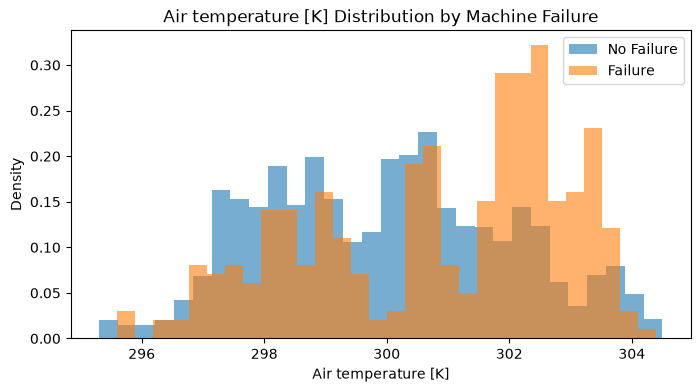

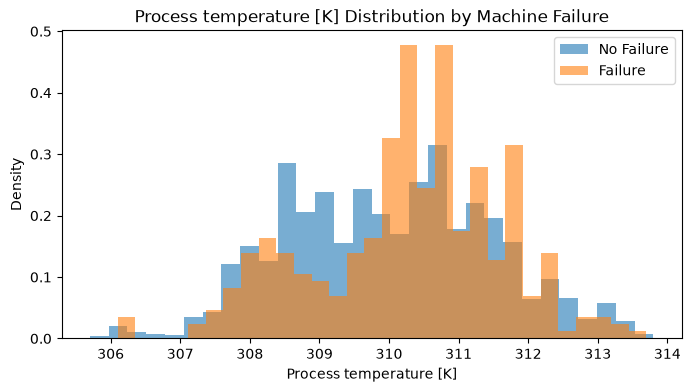

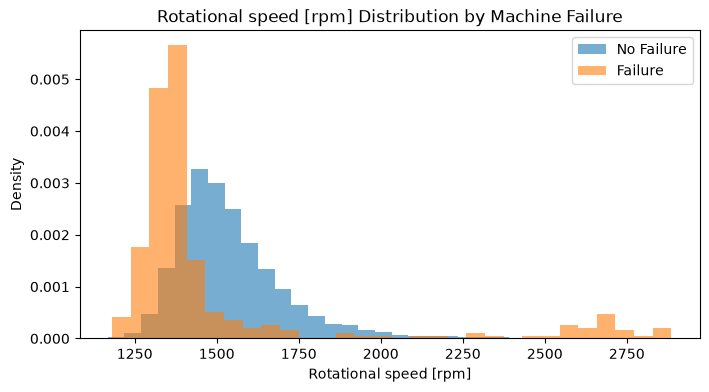

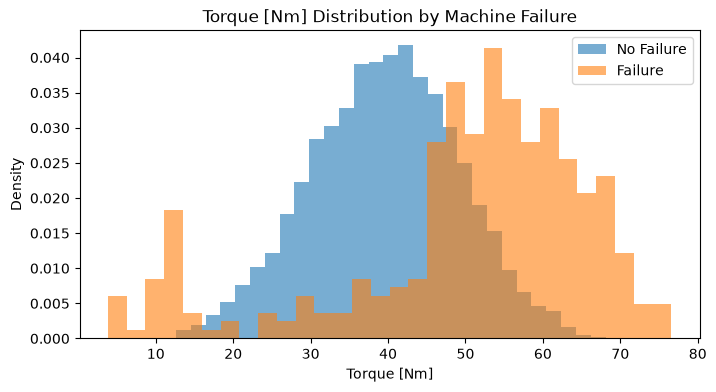

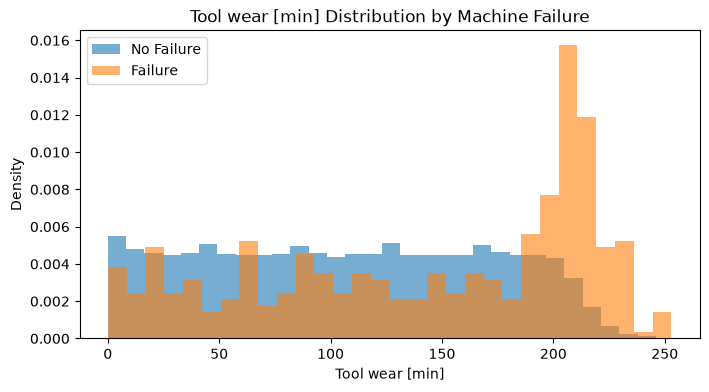

In [18]:
for feature in feature_columns:
    plt.figure(figsize=(8, 4))

    plt.hist(
        df[df["Machine failure"] == 0][feature],
        bins=30,
        alpha=0.6,
        density=True,
        label="No Failure"
    )

    plt.hist(
        df[df["Machine failure"] == 1][feature],
        bins=30,
        alpha=0.6,
        density=True,
        label="Failure"
    )

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(f"{feature} Distribution by Machine Failure")
    plt.legend()
    plt.show()

In [19]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [20]:
pd.crosstab(
    df["Type"],
    df["Machine failure"],
    normalize="index"
) * 100

Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


In [21]:
correlation_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(2)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.00,0.88,0.02,-0.01,0.01,0.08
Process temperature [K],0.88,1.00,0.02,-0.01,0.01,0.04
Rotational speed [rpm],0.02,0.02,1.00,-0.88,0.00,-0.04
Torque [Nm],-0.01,-0.01,-0.88,1.00,-0.00,0.19
Tool wear [min],0.01,0.01,0.00,-0.00,1.00,0.11
Machine failure,0.08,0.04,-0.04,0.19,0.11,1.00
